# 03 - Classification


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


## Load Processed Data


In [3]:
df = pd.read_csv('../data/processed.csv')
X = df.drop(columns=['Machine failure', 'RUL', 'UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], errors='ignore')
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


## Train Models


In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('F1 Score:', f1_score(y_test, y_pred))


F1 Score: 0.8548387096774194


## Confusion Matrix & Feature Importance


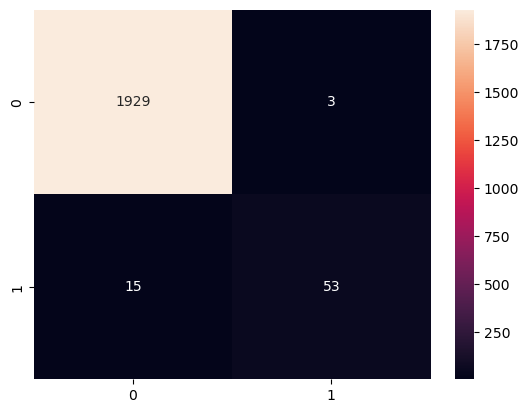

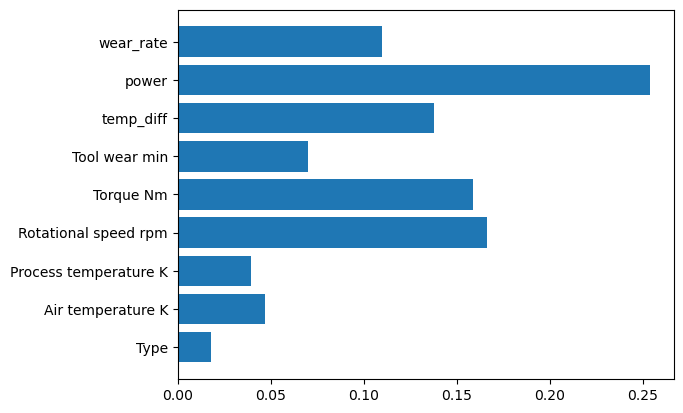

In [7]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

importances = rf.feature_importances_
plt.barh(X.columns, importances)
plt.show()
